In [54]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [61]:
data = pd.read_csv('/content/GSE7904_series_matrix.txt', delimiter = '\t', comment = '!')
data =  data.set_index('ID_REF')
data

,GSM194397,GSM194398,GSM194399,GSM194400,GSM194401,GSM194402,GSM194403,GSM194404,GSM194405,GSM194406,...,GSM194449,GSM194450,GSM194451,GSM194452,GSM194453,GSM194454,GSM194455,GSM194456,GSM194457,GSM194458
ID_REF,,,,,,,,,,,,,,,,,,,,,
1007_s_at,1967.638,636.607,1023.813,3157.591,528.225,1059.527,1073.201,470.421,814.993,1712.225,...,1354.894,1280.560,1052.036,2041.695,1833.868,1517.032,2577.096,1665.917,1496.346,1742.168
1053_at,167.046,201.635,441.165,162.306,144.118,226.185,379.210,65.195,279.983,35.454,...,29.611,56.599,41.081,89.218,103.564,74.407,80.757,70.917,99.775,95.959
117_at,130.689,108.289,244.576,123.292,274.156,133.514,155.897,204.016,147.642,104.973,...,703.967,74.007,139.111,107.604,80.098,145.965,133.467,169.321,85.549,154.670
121_at,352.572,309.747,262.810,278.961,367.984,398.467,422.133,369.867,201.036,437.032,...,677.968,350.596,418.996,211.273,357.454,257.645,295.486,286.660,299.764,262.971
1255_g_at,41.000,24.889,26.642,22.815,21.363,30.252,59.340,19.612,27.508,52.566,...,32.651,34.894,10.643,10.186,27.447,39.923,9.283,55.020,18.138,18.284
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AFFX-ThrX-5_at,19.418,32.333,33.172,30.453,72.386,8.952,17.149,31.965,6.426,61.295,...,33.054,28.664,7.796,18.911,18.731,24.351,30.954,18.499,28.456,33.547
AFFX-ThrX-M_at,138.736,111.792,60.219,70.236,107.703,148.671,84.058,121.656,64.307,97.815,...,135.690,101.495,125.537,98.710,91.997,65.386,62.684,56.737,76.002,97.893
AFFX-TrpnX-3_at,77.261,64.211,49.321,53.270,141.273,99.941,112.910,44.716,69.273,103.250,...,86.796,63.646,60.094,55.725,89.357,71.821,54.611,263.939,85.482,84.230


In [62]:
# data = pd.read_csv('/content/GSE7904_series_matrix.txt', delimiter = '\t', comment = '!')
# data = data.T
# data.columns = data.iloc[0]
# data = data.drop(index = 'ID_REF')
# data

/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


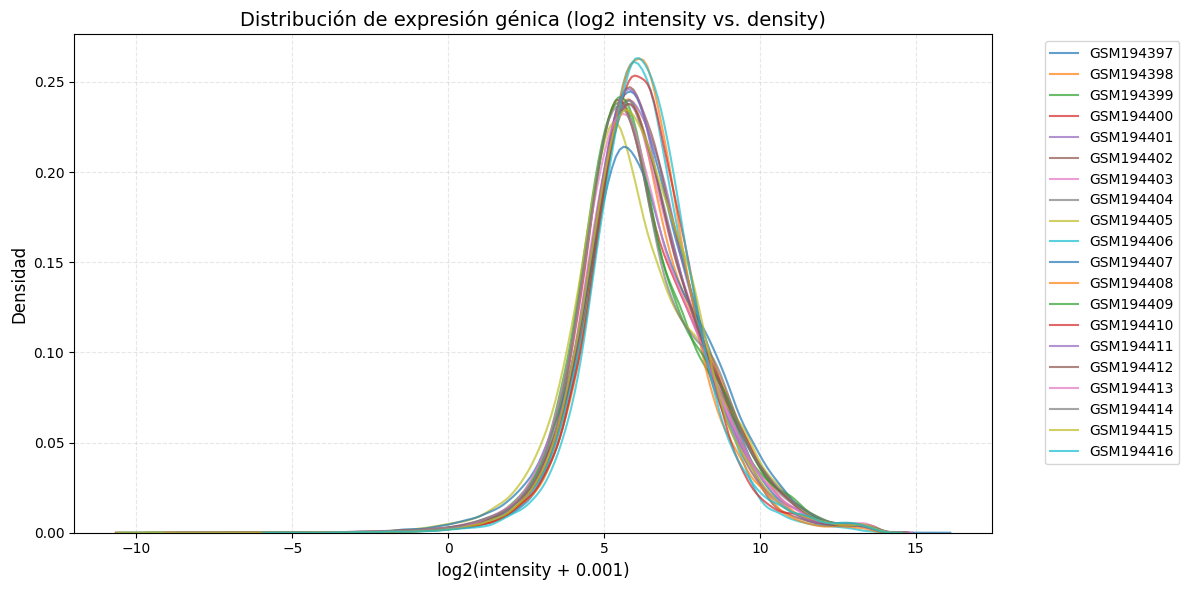

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'data' is your DataFrame loaded from the file
# If not, load it properly (e.g., using pd.read_csv)

# 1. Ensure all columns are numeric (skip non-numeric columns if any)
gene_data = data.copy()

# Convert all columns to numeric, coercing errors (non-numeric values become NaN)
gene_data = gene_data.apply(pd.to_numeric, errors='coerce')

# Drop columns that are entirely NaN (if any)
gene_data = gene_data.dropna(axis=1, how='all')

# 2. Apply log2 transformation with a small offset to avoid -inf
log_gene_data = gene_data.apply(lambda x: np.log2(x + 1e-3))

# 3. Plot the density distributions for the first 20 genes
plt.figure(figsize=(12, 6))
for gene in log_gene_data.columns[:20]:  # Plot first 20 genes
    sns.kdeplot(log_gene_data[gene], label=gene, alpha=0.7, linewidth=1.5)

# 4. Customize the plot
plt.title("Distribución de expresión génica (log2 intensity vs. density)", fontsize=14)
plt.xlabel("log2(intensity + 0.001)", fontsize=12)
plt.ylabel("Densidad", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


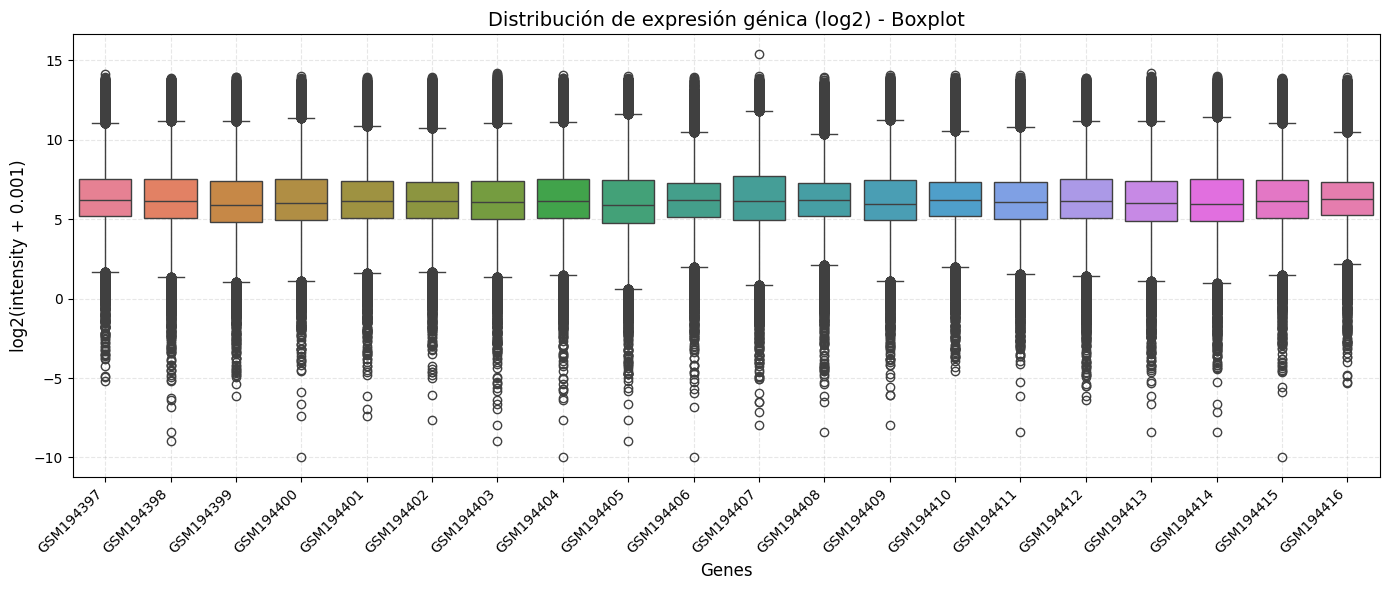

In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Asumimos que 'data' es tu DataFrame original
# 1. Preparar los datos (convertir a numérico y aplicar log2)
gene_data = data.copy()
gene_data = gene_data.apply(pd.to_numeric, errors='coerce')  # Fuerza valores numéricos
gene_data = gene_data.dropna(axis=1, how='all')  # Elimina columnas totalmente vacías
log_gene_data = gene_data.apply(lambda x: np.log2(x + 1e-3))  # Transformación log2

# 2. Crear el boxplot (primeros 20 genes para claridad)
plt.figure(figsize=(14, 6))
sns.boxplot(data=log_gene_data.iloc[:, :20])  # Selecciona las primeras 20 columnas (genes)

# 3. Personalizar el gráfico
plt.title("Distribución de expresión génica (log2) - Boxplot", fontsize=14)
plt.xlabel("Genes", fontsize=12)
plt.ylabel("log2(intensity + 0.001)", fontsize=12)
plt.xticks(rotation=45, ha='right')  # Rota las etiquetas del eje X para mejor legibilidad
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler

def plot_normalization_comparison(data, num_genes=20):
    """
    Muestra gráficos de densidad y boxplots para los datos genéticos después de normalización,
    manejando adecuadamente valores infinitos y extremos.

    Parámetros:
    - data: DataFrame con los datos de expresión génica (genes en columnas)
    - num_genes: Número de genes a visualizar (por defecto 20)
    """
    # Preparar datos originales
    gene_data = data.copy()
    gene_data = gene_data.apply(pd.to_numeric, errors='coerce')
    gene_data = gene_data.dropna(axis=1, how='all')

    # Seleccionar solo los primeros num_genes genes para visualización
    genes_to_plot = gene_data.columns[:num_genes]
    gene_data = gene_data[genes_to_plot]

    # 1. Aplicar transformación log2 con manejo de ceros e infinitos
    log_data = gene_data.apply(lambda x: np.log2(x.replace(0, np.nan) + 1e-3))

    # Eliminar filas con valores infinitos o NaN
    log_data = log_data.replace([np.inf, -np.inf], np.nan).dropna()

    # Verificar si hay datos después de la limpieza
    if log_data.empty:
        raise ValueError("No hay datos válidos después de la limpieza de NaN/inf")

    # Crear figura con subplots
    plt.figure(figsize=(18, 24))

    # 1. Gráficos de densidad original (log2 transformada)
    plt.subplot(4, 2, 1)
    for gene in genes_to_plot:
        sns.kdeplot(log_data[gene], label=gene, alpha=0.7, linewidth=1)
    plt.title("Distribución Original (log2 transformada)")
    plt.xlabel("log2(intensity + 0.001)")
    plt.ylabel("Densidad")
    plt.grid(True, linestyle='--', alpha=0.3)

    # 2. Boxplot original (log2 transformada)
    plt.subplot(4, 2, 2)
    sns.boxplot(data=log_data)
    plt.title("Boxplot Original (log2 transformada)")
    plt.xticks(rotation=90)
    plt.grid(True, linestyle='--', alpha=0.3)

    # 3. Normalización z-score (StandardScaler)
    try:
        scaler = StandardScaler()
        zscore_data = pd.DataFrame(scaler.fit_transform(log_data),
                                 columns=log_data.columns,
                                 index=log_data.index)

        plt.subplot(4, 2, 3)
        for gene in genes_to_plot:
            sns.kdeplot(zscore_data[gene], label=gene, alpha=0.7, linewidth=1)
        plt.title("Normalización Z-score (StandardScaler)")
        plt.xlabel("Valores normalizados")
        plt.ylabel("Densidad")
        plt.grid(True, linestyle='--', alpha=0.3)

        plt.subplot(4, 2, 4)
        sns.boxplot(data=zscore_data)
        plt.title("Boxplot Z-score")
        plt.xticks(rotation=90)
        plt.grid(True, linestyle='--', alpha=0.3)
    except Exception as e:
        print(f"Error en Z-score: {str(e)}")
        plt.subplot(4, 2, 3)
        plt.text(0.5, 0.5, "Error en Z-score", ha='center')
        plt.subplot(4, 2, 4)
        plt.text(0.5, 0.5, "Error en Z-score", ha='center')

    # 4. Normalización RobustScaler
    try:
        robust_scaler = RobustScaler()
        robust_data = pd.DataFrame(robust_scaler.fit_transform(log_data),
                                 columns=log_data.columns,
                                 index=log_data.index)

        plt.subplot(4, 2, 5)
        for gene in genes_to_plot:
            sns.kdeplot(robust_data[gene], label=gene, alpha=0.7, linewidth=1)
        plt.title("Normalización RobustScaler")
        plt.xlabel("Valores normalizados")
        plt.ylabel("Densidad")
        plt.grid(True, linestyle='--', alpha=0.3)

        plt.subplot(4, 2, 6)
        sns.boxplot(data=robust_data)
        plt.title("Boxplot RobustScaler")
        plt.xticks(rotation=90)
        plt.grid(True, linestyle='--', alpha=0.3)
    except Exception as e:
        print(f"Error en RobustScaler: {str(e)}")
        plt.subplot(4, 2, 5)
        plt.text(0.5, 0.5, "Error en RobustScaler", ha='center')
        plt.subplot(4, 2, 6)
        plt.text(0.5, 0.5, "Error en RobustScaler", ha='center')

    # 5. Visualización adicional: Distribución de valores antes/después
    plt.subplot(4, 2, 7)
    sample_gene = genes_to_plot[0] if len(genes_to_plot) > 0 else None
    if sample_gene:
        sns.kdeplot(log_data[sample_gene], label="Original (log2)")
        if 'zscore_data' in locals():
            sns.kdeplot(zscore_data[sample_gene], label="Z-score")
        if 'robust_data' in locals():
            sns.kdeplot(robust_data[sample_gene], label="RobustScaler")
        plt.title(f"Comparación para {sample_gene}")
        plt.xlabel("Valores")
        plt.ylabel("Densidad")
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Devolver los datos normalizados para inspección
    return {
        'log_transformed': log_data,
        'zscore_normalized': zscore_data if 'zscore_data' in locals() else None,
        'robust_normalized': robust_data if 'robust_data' in locals() else None
    }

/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


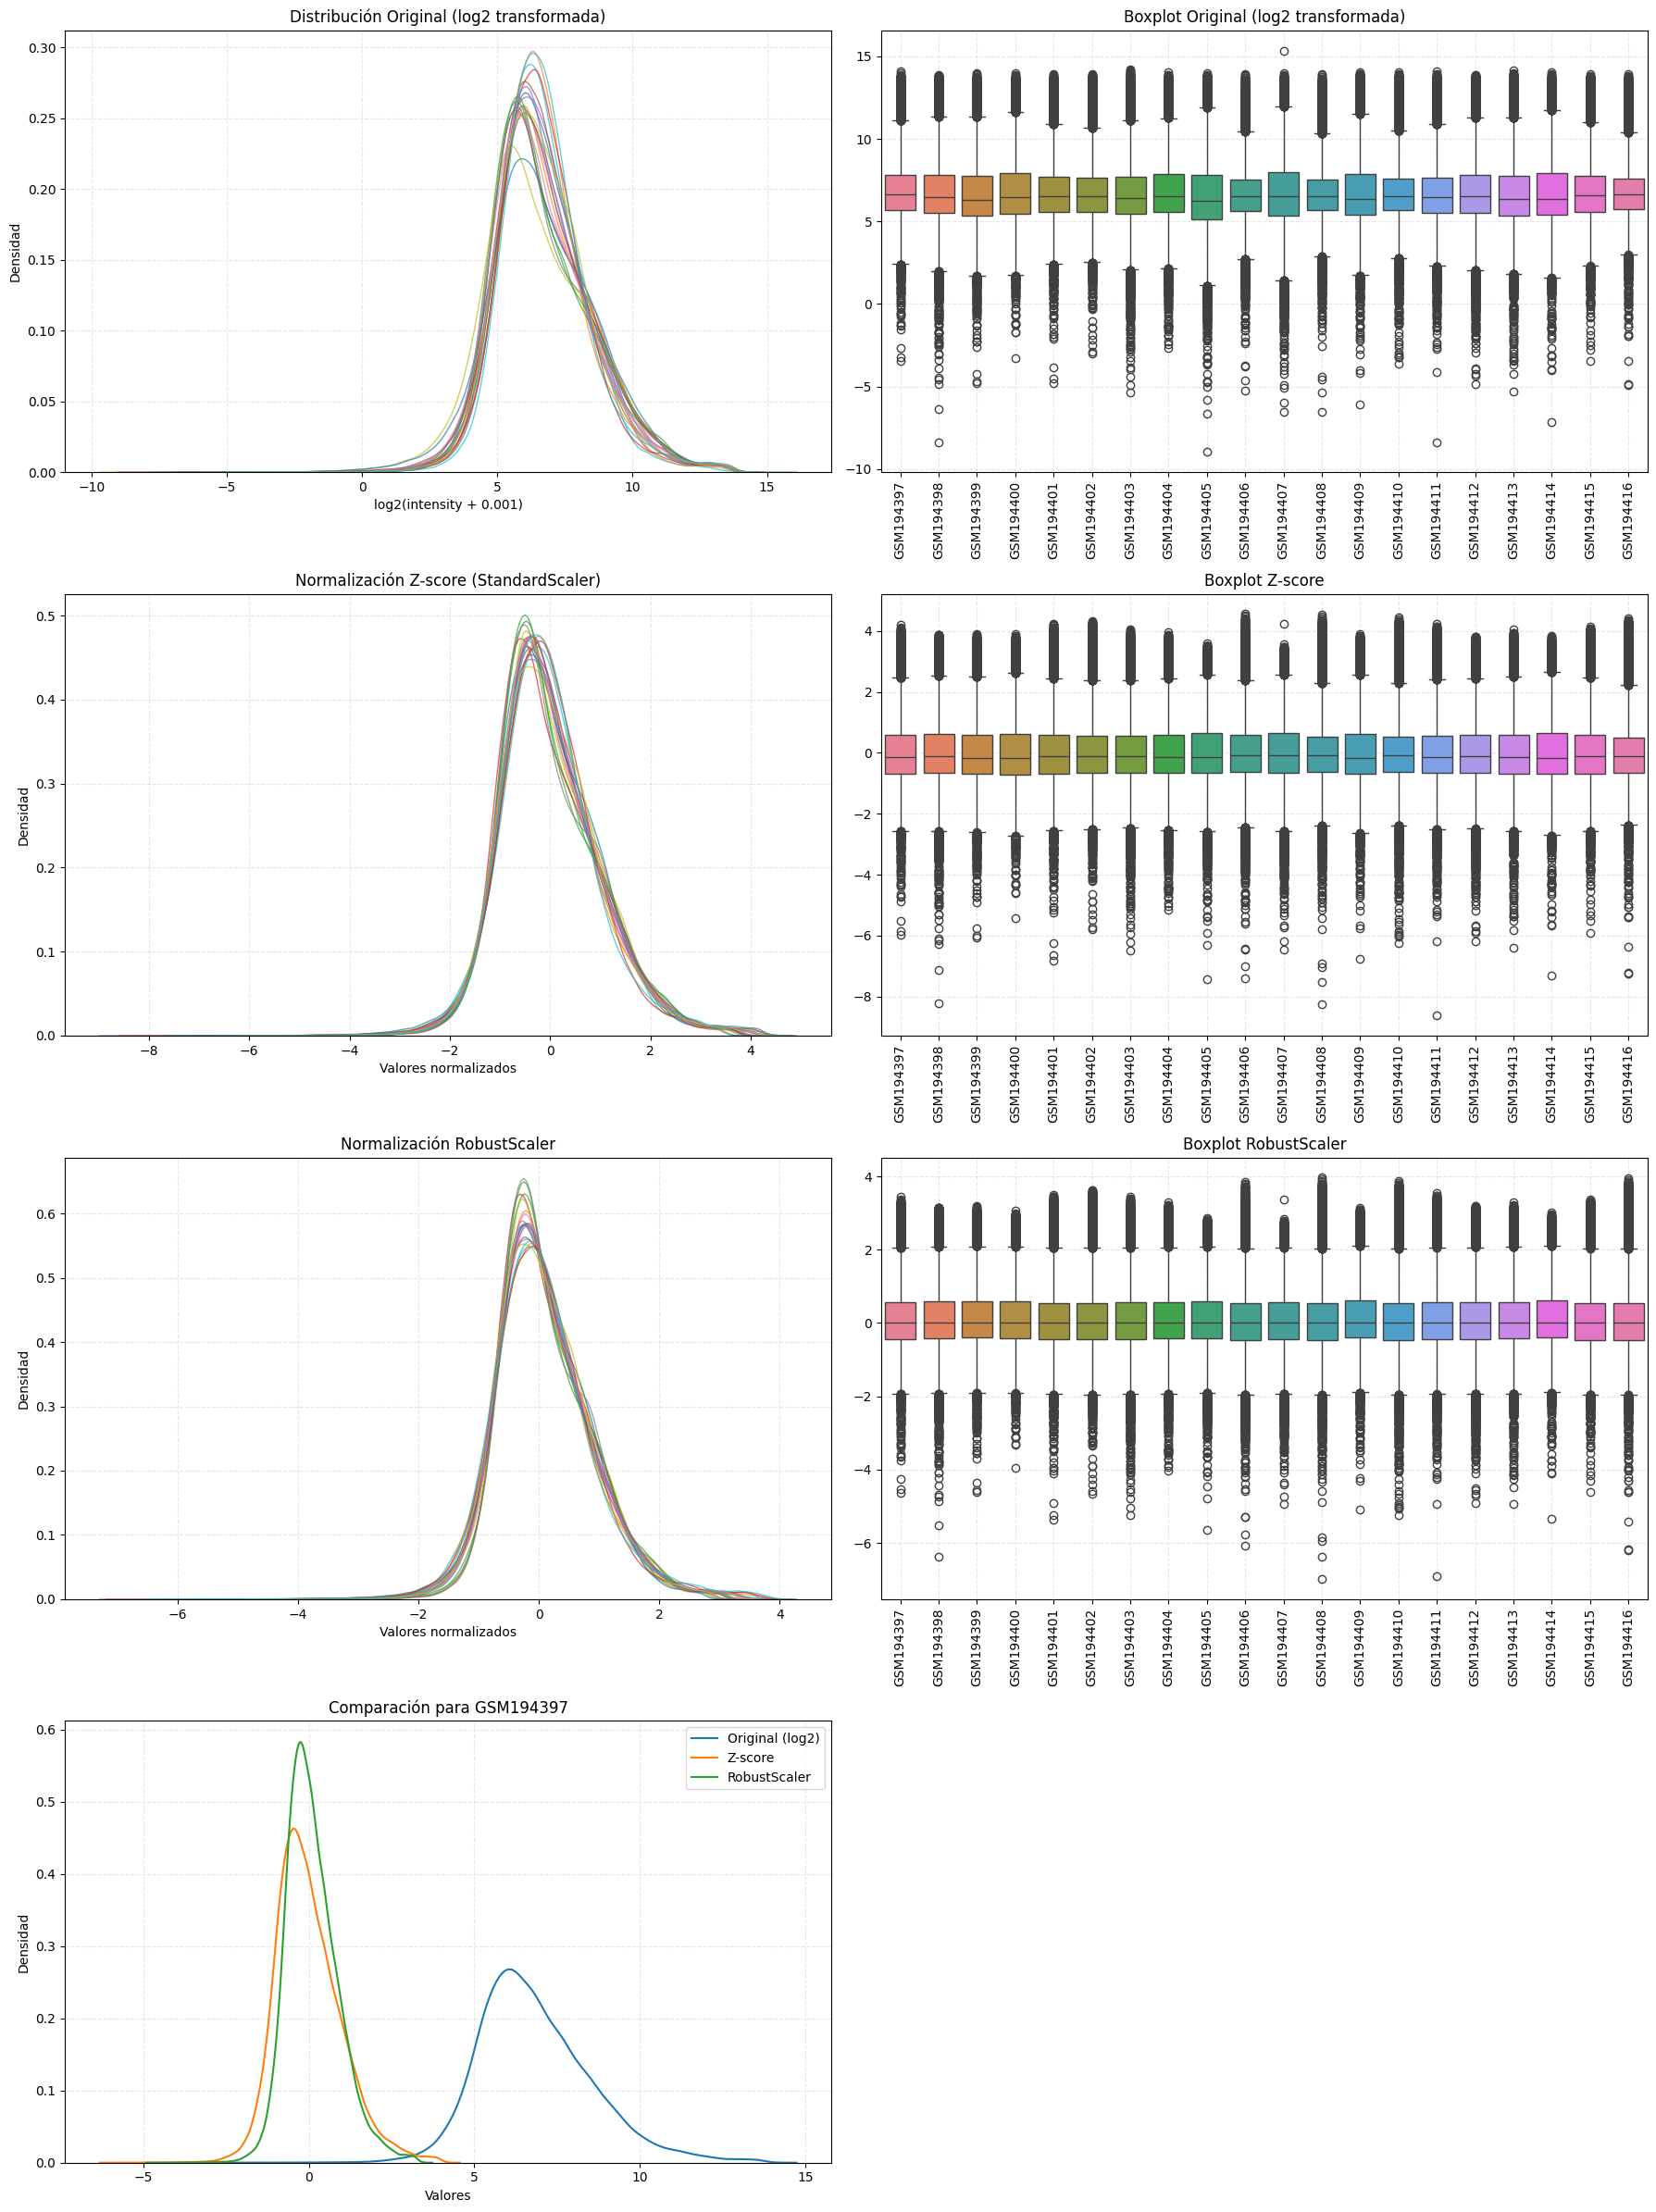

{'log_transformed':                  GSM194397  GSM194398  GSM194399  GSM194400  GSM194401  \
 ID_REF                                                                   
 1007_s_at        10.942250   9.314261   9.999738  11.624609   9.045012   
 1053_at           7.384110   7.655609   8.785178   7.342581   7.171117   
 117_at            7.030005   6.758756   7.934145   6.945947   8.098858   
 121_at            8.461778   8.274951   8.037882   8.123925   8.523503   
 1255_g_at         5.357587   4.637494   4.735685   4.511974   4.417110   
 ...                    ...        ...        ...        ...        ...   
 AFFX-ThrX-3_at    8.109413   8.319993   7.283588   7.050741   8.460136   
 AFFX-ThrX-5_at    4.279397   5.014980   5.051938   4.928560   6.177659   
 AFFX-ThrX-M_at    7.116209   6.804686   5.912171   6.134159   6.750928   
 AFFX-TrpnX-3_at   6.271687   6.004771   5.624159   5.735278   7.142352   
 AFFX-TrpnX-M_at   4.025029   1.517528   3.335140   3.377679   4.432158   
 
    

In [78]:
plot_normalization_comparison(data)